In [ ]:
import subprocess, sys, importlib, pkgutil
def pip_install(*pkgs):
    print(f"pip install {' '.join(pkgs)} ...")
    r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs],
                       capture_output=True, text=True)
    if r.returncode != 0:
        print("pip STDOUT:", r.stdout[-2000:])
        print("pip STDERR:", r.stderr[-2000:])
        raise RuntimeError("pip install failed; see output above.")
    print("  ok")

pip_install("numpy>=2.0,<2.3")
pip_install("neuralset")
pip_install("neuralfetch")

import numpy as np
from numpy._core.umath import _center
print(f"numpy {np.__version__} OK")

import warnings, typing as tp
warnings.filterwarnings("ignore")
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

import neuralset as ns
from neuralset import extractors as ext_mod

In [ ]:
def deep_import(pkg_name: str):
    try:
        pkg = importlib.import_module(pkg_name)
    except Exception as e:
        print(f"⚠️  could not import {pkg_name}: {e}")
        return
    if not hasattr(pkg, "__path__"):
        return
    for m in pkgutil.walk_packages(pkg.__path__, prefix=pkg_name + "."):
        try:
            importlib.import_module(m.name)
        except Exception:
            pass

deep_import("neuralfetch")
deep_import("neuralset")

torch.manual_seed(0); np.random.seed(0)

catalog = ns.Study.catalog()
print(f"\n{len(catalog)} studies registered.")
preferred = ["Fake2025Meg", "Test2025Meg", "Test2023Meg"]
study_name = next((n for n in preferred if n in catalog), None)

if study_name is None:
    meg_studies = [n for n, c in catalog.items() if "Meg" in c.neuro_types()]
    study_name = meg_studies[0] if meg_studies else None

if study_name is None:
    raise RuntimeError(
        "No MEG study available. Catalog: "
        f"{sorted(catalog.keys())[:20]}…  "
        "Install neuralfetch correctly (pip install neuralfetch) and re-run."
    )
print(f"→ Using study: {study_name}")

In [ ]:
class CharCount(ext_mod.BaseStatic):
    event_types: tp.Literal["Word"] = "Word"
    def get_static(self, event) -> torch.Tensor:
        return torch.tensor([float(len(event.text))], dtype=torch.float32)

print("\nBuilding chain...")
chain = ns.Chain(steps=[
    {"name": study_name, "path": str(ns.CACHE_FOLDER)},
    {"name": "QueryEvents", "query": "type in ['Word', 'Meg']"},
])
events = chain.run()
print(f"  → {len(events)} events; types={sorted(events.type.unique().tolist())}")
print(f"  → Words: {(events.type=='Word').sum()} | "
      f"timelines: {events.timeline.nunique()}")
print("\nSample words:")
print(events[events.type=='Word'][["start","duration","text","timeline"]]
      .head(5).to_string(index=False))

print("\nBuilding segmenter...")
segmenter = ns.dataloader.Segmenter(
    extractors={
        "meg":        {"name": "MegExtractor", "frequency": 100.0},
        "char_count": CharCount(aggregation="trigger"),
    },
    trigger_query="type == 'Word'",
    start=-0.2, duration=0.8,
    drop_incomplete=True,
)
dataset = segmenter.apply(events)
print(f"  → SegmentDataset: {len(dataset)} segments")

s0 = dataset[0]
print(f"\nSingle item:\n  meg        : {tuple(s0.data['meg'].shape)}")
print(f"  char_count : {s0.data['char_count'].item()}  "
      f"(word: {s0.segments[0].trigger.text!r})")

In [ ]:
rng  = np.random.RandomState(42)
perm = rng.permutation(len(dataset))
n_tr, n_va = int(0.70*len(dataset)), int(0.15*len(dataset))
train_ds = dataset.select(perm[:n_tr])
val_ds   = dataset.select(perm[n_tr:n_tr+n_va])
test_ds  = dataset.select(perm[n_tr+n_va:])
print(f"\nSplit | train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

mk = lambda d, sh: DataLoader(d, batch_size=32, shuffle=sh,
                              collate_fn=d.collate_fn, drop_last=False)
train_loader, val_loader, test_loader = mk(train_ds, True), mk(val_ds, False), mk(test_ds, False)

probe = next(iter(train_loader))
n_ch, n_t = probe.data["meg"].shape[-2:]
print(f"  → batch[meg]  shape: {tuple(probe.data['meg'].shape)}")
print(f"  → batch[char] shape: {tuple(probe.data['char_count'].shape)}")

class MEGDecoder(nn.Module):
    def __init__(self, n_channels: int, mid: int = 64):
        super().__init__()
        self.spatial   = nn.Conv1d(n_channels, mid, 1)
        self.bn0       = nn.BatchNorm1d(mid)
        self.temporal1 = nn.Conv1d(mid, mid, 7, padding=3)
        self.bn1       = nn.BatchNorm1d(mid)
        self.temporal2 = nn.Conv1d(mid, mid//2, 7, padding=3)
        self.bn2       = nn.BatchNorm1d(mid//2)
        self.pool      = nn.AdaptiveAvgPool1d(1)
        self.head      = nn.Linear(mid//2, 1)
        self.drop      = nn.Dropout(0.3)
    def forward(self, x):
        x = F.gelu(self.bn0(self.spatial(x)))
        x = F.gelu(self.bn1(self.temporal1(x)))
        x = self.drop(x)
        x = F.gelu(self.bn2(self.temporal2(x)))
        return self.head(self.pool(x).squeeze(-1)).squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = MEGDecoder(n_channels=n_ch).to(device)
print(f"\nDevice: {device} | params: {sum(p.numel() for p in model.parameters()):,}")

train_targets = torch.cat([b.data["char_count"].squeeze(-1) for b in train_loader])
y_mean, y_std = train_targets.mean().item(), train_targets.std().item() + 1e-6
print(f"Target  μ={y_mean:.2f}  σ={y_std:.2f}")

def prep(batch):
    x = batch.data["meg"].to(device).float()
    y = batch.data["char_count"].squeeze(-1).to(device).float()
    x = (x - x.mean(-1, keepdim=True)) / (x.std(-1, keepdim=True) + 1e-6)
    y = (y - y_mean) / y_std
    return x, y

pip install numpy>=2.0,<2.3 ...
  ok
pip install neuralset ...
  ok
pip install neuralfetch ...
  ok
numpy 2.4.4 OK

20 studies registered.
→ Using study: Fake2025Meg

Building chain...


100%|██████████| 2/2 [00:01<00:00,  1.52it/s]


  → 578 events; types=['Meg', 'Word']
  → Words: 576 | timelines: 2

Sample words:
    start  duration   text                    timeline
46.578924       0.2 bottom Fake2025Meg:subject=sample0
47.191629       0.2   left Fake2025Meg:subject=sample0
47.897572       0.2    top Fake2025Meg:subject=sample0
48.643475       0.2  right Fake2025Meg:subject=sample0
49.369397       0.2 bottom Fake2025Meg:subject=sample0

Building segmenter...
  → SegmentDataset: 576 segments

Single item:
  meg        : (1, 306, 80)
  char_count : 6.0  (word: 'bottom')

Split | train=403  val=86  test=87
  → batch[meg]  shape: (32, 306, 80)
  → batch[char] shape: (32, 1)

Device: cpu | params: 63,105
Target  μ=4.50  σ=1.10

Epoch |     train |       val |   val_r
    1 |    0.9941 |    1.1415 |  +0.347
    2 |    0.9144 |    1.1422 |  +0.396
    3 |    0.8061 |    1.1516 |  +0.381
    4 |    0.7071 |    1.1356 |  +0.338
    5 |    0.6157 |    1.6125 |  +0.312
    6 |    0.5202 |   21.0867 |  +0.333
    7 |    0.4

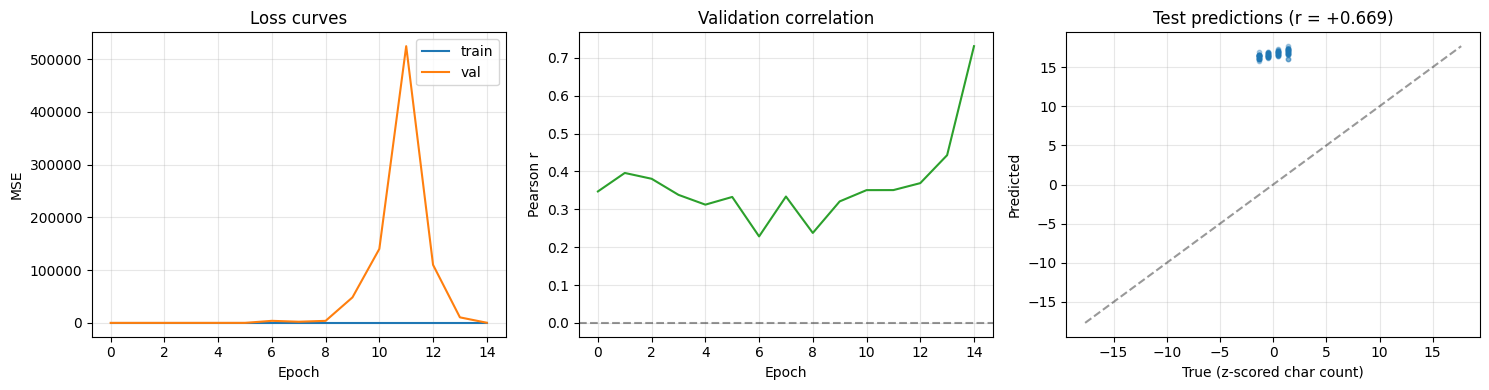


✅ Tutorial complete!
  • Study used        : Fake2025Meg
  • Pipeline          : Chain → Segmenter → SegmentDataset → DataLoader
  • Custom extractor  : CharCount (subclass of BaseStatic)
  • Built-in extractor: MegExtractor @ 100 Hz
  • Model             : 1×1 spatial conv + 2 temporal convs + linear head


In [5]:
EPOCHS  = 15
opt     = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
sched   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
loss_fn = nn.MSELoss()
hist    = {"tr": [], "va": [], "r": []}

def pearson(a, b):
    a, b = a - a.mean(), b - b.mean()
    return (a*b).sum() / (a.norm()*b.norm() + 1e-8)

print("\n" + "="*64)
print(f"{'Epoch':>5} | {'train':>9} | {'val':>9} | {'val_r':>7}")
print("="*64)
for ep in range(EPOCHS):
    model.train(); tr = []
    for batch in train_loader:
        x, y = prep(batch)
        loss = loss_fn(model(x), y)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); tr.append(loss.item())
    sched.step()

    model.eval(); va, P, T = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            x, y = prep(batch); p = model(x)
            va.append(loss_fn(p, y).item()); P.append(p.cpu()); T.append(y.cpu())
    P, T = torch.cat(P), torch.cat(T)
    r = pearson(P, T).item()
    hist["tr"].append(np.mean(tr)); hist["va"].append(np.mean(va)); hist["r"].append(r)
    print(f"{ep+1:>5d} | {np.mean(tr):>9.4f} | {np.mean(va):>9.4f} | {r:>+7.3f}")

model.eval(); P, T = [], []
with torch.no_grad():
    for batch in test_loader:
        x, y = prep(batch)
        P.append(model(x).cpu()); T.append(y.cpu())
P, T = torch.cat(P), torch.cat(T)
test_r   = pearson(P, T).item()
test_mse = ((P - T) ** 2).mean().item()
print(f"\nTEST  |  Pearson r = {test_r:+.3f}   MSE = {test_mse:.3f}")
print(f"(Synthetic-MEG signals are random by design — small/zero r is expected.)")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(hist["tr"], label="train"); ax[0].plot(hist["va"], label="val")
ax[0].set(xlabel="Epoch", ylabel="MSE", title="Loss curves"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(hist["r"], color="C2"); ax[1].axhline(0, color="k", ls="--", alpha=.4)
ax[1].set(xlabel="Epoch", ylabel="Pearson r", title="Validation correlation"); ax[1].grid(alpha=.3)
m = float(max(T.abs().max(), P.abs().max()))
ax[2].scatter(T.numpy(), P.numpy(), s=10, alpha=.35)
ax[2].plot([-m, m], [-m, m], "k--", alpha=.4)
ax[2].set(xlabel="True (z-scored char count)", ylabel="Predicted",
          title=f"Test predictions (r = {test_r:+.3f})"); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

print("\n✅ Tutorial complete!")
print(f"  • Study used        : {study_name}")
print(f"  • Pipeline          : Chain → Segmenter → SegmentDataset → DataLoader")
print(f"  • Custom extractor  : CharCount (subclass of BaseStatic)")
print(f"  • Built-in extractor: MegExtractor @ 100 Hz")
print(f"  • Model             : 1×1 spatial conv + 2 temporal convs + linear head")